# CHronoZ Benchmark Modelling
## PPIACO Delta Distribution Audit

**Normalization, Historical Range Marking, and Tail Detection**

Audit layer for [analysis.ipynb](analysis.ipynb), using the cleaned repository snapshot. Run all cells from the repository or a notebook subfolder; dependencies are in requirements-notebook.txt. Figures and results are saved inline.

## 1. Load and validate data

The native price-index level provides context. Its historical scale changes substantially over time, so the raw historical level is not the final benchmark variable. This audit studies proportional monthly movement.

observations,start,end,missing_values,inferred_frequency,native_frequency,gap_pairs,missing_rows_removed_in_cleaning
1364,1913-01-01,2026-08-01,0,MS,monthly,0,0


**First observations**

date,level
1913-01-01,12.1
1913-02-01,12
1913-03-01,12
1913-04-01,12
1913-05-01,11.9


**Last observations**

date,level
2026-04-01,282.722
2026-05-01,290.2
2026-06-01,286.023
2026-07-01,285.181
2026-08-01,287.928


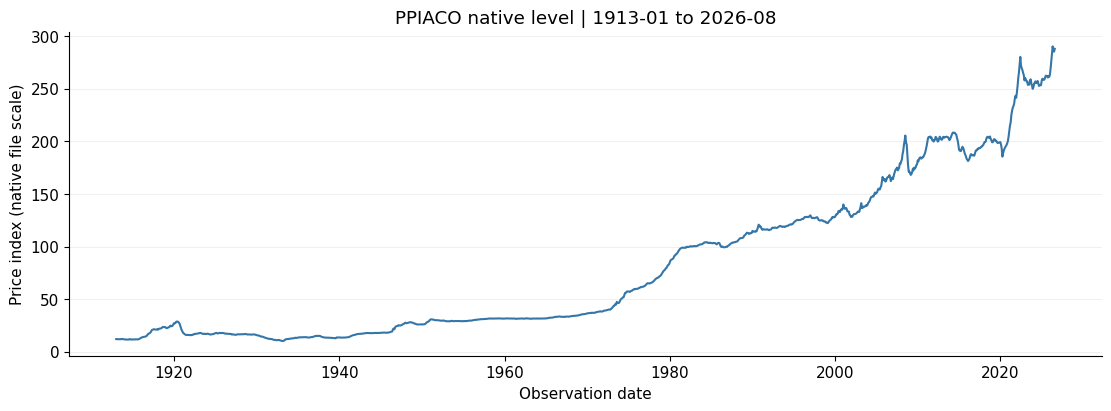

Source: FRED in repository metadata. Index-base and seasonal-adjustment metadata are not supplied; no additional adjustment is applied.

In [1]:
from pathlib import Path
import hashlib,platform,warnings
import numpy as np
import pandas as pd
import scipy,statsmodels,matplotlib
from scipy.stats import gaussian_kde
from statsmodels.tsa.stattools import adfuller,kpss
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display,Markdown,HTML
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'data/cleaned/PPIACO.csv').is_file()),None)
if ROOT is None:raise FileNotFoundError('Run inside the repository.')
SOURCE=ROOT/'data/cleaned/PPIACO.csv'
REFERENCE=ROOT/'notebook/deltaAnalysis/analysis.ipynb'
def digest(p):return hashlib.sha256(p.read_bytes()).hexdigest()
protected=list((ROOT/'data/cleaned').glob('*.csv'))+[REFERENCE]
source_hashes={str(p.relative_to(ROOT)):digest(p) for p in protected}
def table(frame):display(HTML(frame.to_html(index=False,float_format=lambda v:f'{v:,.6g}',escape=True)))
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':11,'figure.facecolor':'white','figure.dpi':100,'axes.spines.top':False,'axes.spines.right':False})
metadata=pd.read_csv(ROOT/'data/cleaned/series_metadata.csv').set_index('series_id').loc['PPIACO']
audit=pd.read_csv(ROOT/'data/audit/data_cleaning_audit.csv').set_index('series_id').loc['PPIACO']
raw=pd.read_csv(SOURCE);assert list(raw)==['date','value']
data=raw.rename(columns={'value':'level'}).copy()
data['date']=pd.to_datetime(data.date,errors='raise');data['level']=pd.to_numeric(data.level,errors='raise')
assert data.date.notna().all() and data.date.is_unique and data.date.is_monotonic_increasing
assert np.isfinite(data.level).all() and data.level.gt(0).all()
assert len(data)==metadata.valid_observations==audit.clean_rows
periods=data.date.dt.to_period('M');consecutive=periods.astype('int64').diff().eq(1)
gap_pairs=int((~consecutive.iloc[1:]).sum());frequency=pd.infer_freq(data.date)
assert metadata.expected_frequency=='monthly' and periods.is_unique and frequency in {'MS','ME','M'}
assert gap_pairs==0,'Unexpected gaps: investigate before proceeding; never bridge missing months.'
table(pd.DataFrame([{'observations':len(data),'start':data.date.min(),'end':data.date.max(),
 'missing_values':int(data.isna().sum().sum()),'inferred_frequency':frequency,'native_frequency':'monthly',
 'gap_pairs':gap_pairs,'missing_rows_removed_in_cleaning':audit.missing_value_rows_removed}]))
display(Markdown('**First observations**'));table(data.head())
display(Markdown('**Last observations**'));table(data.tail())
fig,ax=plt.subplots(figsize=(11,4),layout='constrained')
ax.plot(data.date,data.level,color='#3576A8')
ax.set(title=f'PPIACO native level | {data.date.min():%Y-%m} to {data.date.max():%Y-%m}',xlabel='Observation date',ylabel='Price index (native file scale)')
ax.grid(axis='y',alpha=.18);plt.show();plt.close(fig)
display(Markdown('Source: FRED in repository metadata. Index-base and seasonal-adjustment metadata are not supplied; no additional adjustment is applied.'))


## 2. Transform into one-month log changes

$$\Delta_t=100\ln(PPIACO_t/PPIACO_{t-1}).$$

PPIACO is positive. Proportional changes are more comparable across decades than raw index-point changes because the index level changes substantially. Log growth creates a common movement scale: approximately monthly percent for small changes, not exact percent for large changes. It is not annualized.

Retain date, level, and delta_log_pct. Only the initial row lacks a predecessor. No tails are removed, clipped, or winsorized; consecutive-month checks guard against changes across gaps.

In [2]:
data['previous_level']=data.level.shift(1)
data['delta_log_pct']=(100*np.log(data.level/data.previous_level)).where(consecutive)
assert data.delta_log_pct.iloc[0:].isna().sum()==1
valid=data.loc[data.delta_log_pct.notna()].copy();delta=valid.delta_log_pct
assert len(valid)==len(data)-1 and np.isfinite(delta).all()
np.testing.assert_allclose(delta,(100*np.log(data.level).diff()).iloc[1:],atol=1e-11)
table(data[['date','level','delta_log_pct']].head())
print(len(valid),'valid monthly changes; all tails retained.')


date,level,delta_log_pct
1913-01-01,12.1,NaN
1913-02-01,12,-0.82988
1913-03-01,12,0
1913-04-01,12,0
1913-05-01,11.9,-0.836825


1363 valid monthly changes; all tails retained.


## 3. Describe the delta distribution

Sample standard deviation uses ddof=1. Quantiles use linear interpolation. Skewness and excess kurtosis use bias-corrected sample estimators; excess kurtosis has normal-reference value zero, without assuming normality. IQR = P75 - P25.

Histogram bins use NumPy auto, capped at 80. KDE uses Gaussian kernels and Scott bandwidth as a visual smoothing guide, not a fitted economic model. Repeated rounded values mean KDE may suggest smoothness absent in the recorded observations.

statistic,value
observations,"1,363"
mean,0.232539
median,0.158353
standard_deviation,1.27941
minimum,-10.0541
maximum,10.278
P01,-3.37249
P05,-1.50343
P10,-0.863057
P25,-0.242723


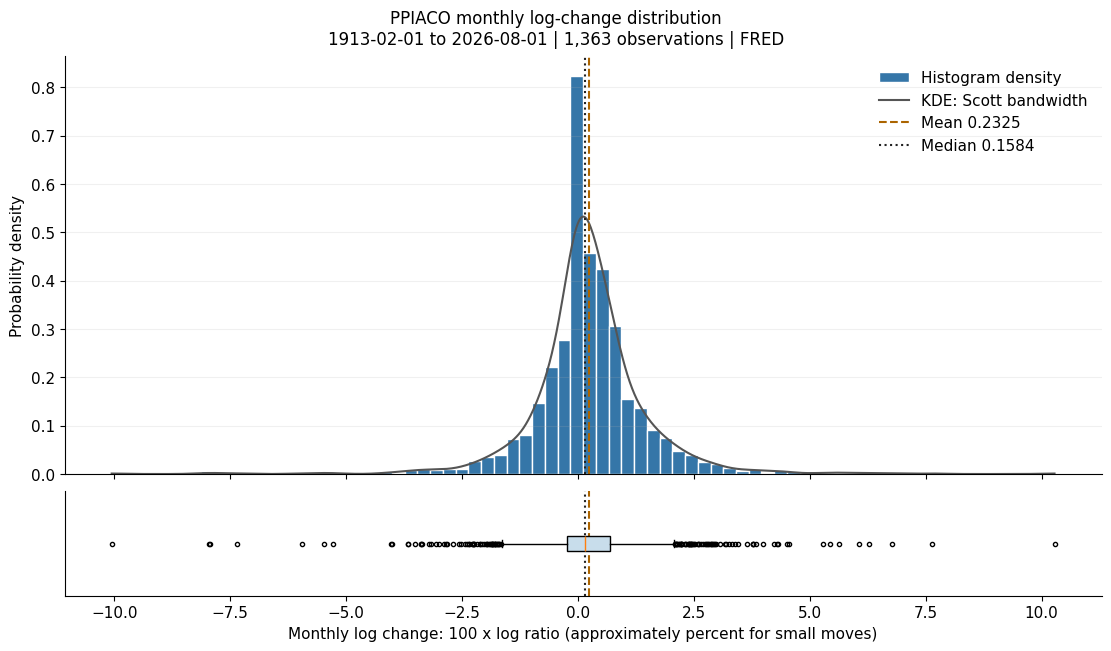

In [3]:
mu=float(delta.mean());sigma=float(delta.std(ddof=1));assert sigma>0
q=delta.quantile([.01,.05,.10,.25,.50,.75,.90,.95,.99])
metrics={'observations':len(delta),'mean':mu,'median':delta.median(),'standard_deviation':sigma,
 'minimum':delta.min(),'maximum':delta.max(),**{f'P{int(p*100):02d}':v for p,v in q.items()},
 'skewness':delta.skew(),'excess_kurtosis':delta.kurt(),'IQR':q.loc[.75]-q.loc[.25]}
table(pd.DataFrame({'statistic':metrics.keys(),'value':metrics.values()}))
edges=np.histogram_bin_edges(delta,bins='auto')
if len(edges)-1>80:edges=np.linspace(delta.min(),delta.max(),81)
assert np.histogram(delta,bins=edges)[0].sum()==len(delta)
fig,(ax,box)=plt.subplots(2,1,figsize=(11,6.4),sharex=True,gridspec_kw={'height_ratios':[4,1]},layout='constrained')
ax.hist(delta,bins=edges,density=True,color='#3576A8',edgecolor='white',label='Histogram density')
grid=np.linspace(delta.min(),delta.max(),800)
ax.plot(grid,gaussian_kde(delta,bw_method='scott')(grid),color='#555555',label='KDE: Scott bandwidth')
for panel in (ax,box):
 panel.axvline(mu,color='#AB6400',ls='--',label=f'Mean {mu:.4f}')
 panel.axvline(delta.median(),color='#222222',ls=':',label=f'Median {delta.median():.4f}')
box.boxplot(delta,orientation='horizontal',patch_artist=True,boxprops={'facecolor':'#C8DDEB'},flierprops={'markersize':3,'markerfacecolor':'none'})
box.set_yticks([]);box.set_xlabel('Monthly log change: 100 x log ratio (approximately percent for small moves)')
ax.set_ylabel('Probability density');ax.legend(frameon=False);ax.grid(axis='y',alpha=.18)
fig.suptitle(f'PPIACO monthly log-change distribution\n{valid.date.min():%Y-%m-%d} to {valid.date.max():%Y-%m-%d} | {len(valid):,} observations | FRED',fontsize=12)
plt.show();plt.close(fig)


## 4. Historical normalization

$$z_t=(\Delta_t-\bar\Delta)/s_\Delta,\qquad F_n(\Delta_t)=\#\{i:\Delta_i\leq\Delta_t\}/n.$$

The goal is **not to force PPIACO into a Gaussian distribution**. It is to place each monthly movement relative to its own historical Delta Distribution. Percentile rank = 100 times empirical CDF. Ties receive the same upper rank (count less than or equal); ranks are historical positions, not forecasts.

The full available sample, **including the latest observation**, supplies the reference. Historical labels use later observations retrospectively. This is not a look-ahead-free signal, backtest, or release-vintage analysis. Positive/negative z means above/below the historical **mean change**, not necessarily a rising/falling index.

In [4]:
valid['z_delta']=(delta-mu)/sigma
valid['percentile_rank']=100*delta.rank(method='max')/len(delta)
assert np.isclose(valid.z_delta.mean(),0,atol=1e-12) and np.isclose(valid.z_delta.std(ddof=1),1)
np.testing.assert_allclose(valid.percentile_rank,100*np.searchsorted(np.sort(delta),delta,side='right')/len(delta))
table(valid[['date','level','delta_log_pct','z_delta','percentile_rank']].tail())


date,level,delta_log_pct,z_delta,percentile_rank
2026-04-01,282.722,2.36684,1.66819,96.0382
2026-05-01,290.2,2.61063,1.85874,97.0653
2026-06-01,286.023,-1.44981,-1.31494,5.79604
2026-07-01,285.181,-0.294816,-0.412186,24.0646
2026-08-01,287.928,0.958638,0.567527,82.6119


## 5. Statistical marking ranges

Initial audit categories, not Gaussian probability claims. Intervals include the lower boundary and exclude the upper boundary. CENTRAL has no directional suffix; other states preserve the sign of z.

| Absolute z | Classification |
| --- | --- |
| [0, 0.5) | CENTRAL |
| [0.5, 1) | NORMAL POSITIVE / NEGATIVE |
| [1, 2) | ELEVATED POSITIVE / NEGATIVE |
| [2, 3) | EXTREME POSITIVE / NEGATIVE |
| [3, infinity) | SPIKE POSITIVE / NEGATIVE |


In [5]:
def classify_z(z):
 if abs(z)<.5:return 'CENTRAL'
 band='NORMAL' if abs(z)<1 else 'ELEVATED' if abs(z)<2 else 'EXTREME' if abs(z)<3 else 'SPIKE'
 return band+(' POSITIVE' if z>0 else ' NEGATIVE')
assert [classify_z(x) for x in [0,.5,-1,2.4,-2.4,3,-3]]==['CENTRAL','NORMAL POSITIVE','ELEVATED NEGATIVE','EXTREME POSITIVE','EXTREME NEGATIVE','SPIKE POSITIVE','SPIKE NEGATIVE']
valid['delta_state']=valid.z_delta.map(classify_z)
counts=valid.delta_state.value_counts().rename_axis('delta_state').reset_index(name='observations')
counts['percent_of_history']=100*counts.observations/len(valid)
assert counts.observations.sum()==len(valid);table(counts)


delta_state,observations,percent_of_history
CENTRAL,830,60.8951
NORMAL NEGATIVE,145,10.6383
NORMAL POSITIVE,137,10.0514
ELEVATED POSITIVE,96,7.04329
ELEVATED NEGATIVE,90,6.60308
EXTREME POSITIVE,23,1.68745
EXTREME NEGATIVE,18,1.32062
SPIKE POSITIVE,13,0.953778
SPIKE NEGATIVE,11,0.807043


## 6. Empirical distribution bands

Nested sample-quantile ranges provide a second reference, not equivalents of z bands. Below P5 or above P95 is a TAIL OBSERVATION. Boundary values remain inside the outer range. Ties can make observed coverage differ from nominal percentile widths.

In [6]:
bands=pd.DataFrame([{'range':name,'lower_percentile':f'P{int(a*100)}','upper_percentile':f'P{int(b*100)}',
 'lower_delta':q.loc[a],'upper_delta':q.loc[b],'observed_coverage_pct':100*delta.between(q.loc[a],q.loc[b]).mean()}
 for name,a,b in [('CENTRAL HISTORICAL RANGE',.25,.75),('NORMAL HISTORICAL RANGE',.10,.90),('OUTER HISTORICAL RANGE',.05,.95)]])
table(bands)
valid['empirical_tail']=(delta<q.loc[.05])|(delta>q.loc[.95])
print(f'Tail: below {q.loc[.05]:.6f} or above {q.loc[.95]:.6f} monthly log-change units.')


range,lower_percentile,upper_percentile,lower_delta,upper_delta,observed_coverage_pct
CENTRAL HISTORICAL RANGE,P25,P75,-0.242723,0.68929,49.9633
NORMAL HISTORICAL RANGE,P10,P90,-0.863057,1.48645,79.8973
OUTER HISTORICAL RANGE,P5,P95,-1.50343,2.1098,89.8753


Tail: below -1.503427 or above 2.109799 monthly log-change units.


## 7. Normalized range visualization

The full z range is retained. Shaded zones show absolute distance from the historical mean; NORMAL is a category name, not a normality assumption. Line styles distinguish the mean, median, sigma boundaries, and empirical P5/P95.

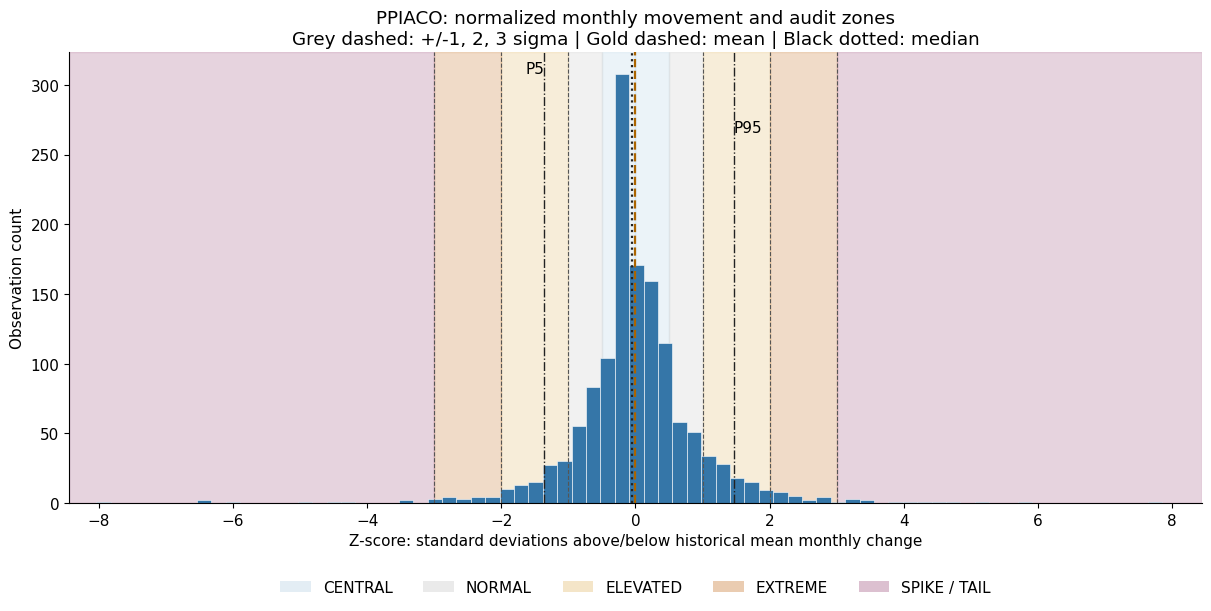

In [7]:
z=valid.z_delta;limit=max(3.5,float(z.abs().max())*1.05)
zones=[(0,.5,'CENTRAL','#C8DDEB'),(.5,1,'NORMAL','#D7D7D7'),(1,2,'ELEVATED','#EACD92'),
       (2,3,'EXTREME','#D69A64'),(3,limit,'SPIKE / TAIL','#BA82A3')]
fig,ax=plt.subplots(figsize=(12,6),layout='constrained')
for low,high,label,color in zones:
 ax.axvspan(low,high,color=color,alpha=.35);ax.axvspan(-high,-low,color=color,alpha=.35)
ax.hist(z,bins=(edges-mu)/sigma,color='#3576A8',edgecolor='white',linewidth=.4)
for boundary in [-3,-2,-1,1,2,3]:ax.axvline(boundary,color='#555555',ls='--',lw=.8)
ax.axvline(0,color='#AB6400',ls='--',lw=1.6)
ax.axvline((delta.median()-mu)/sigma,color='#222222',ls=':',lw=1.6)
for prob in [.05,.95]:
 position=(q.loc[prob]-mu)/sigma
 ax.axvline(position,color='#222222',ls='-.',lw=1)
 ax.text(position,.98 if prob==.05 else .85,f'P{int(prob*100)}',transform=ax.get_xaxis_transform(),ha='right' if prob==.05 else 'left',va='top')
ax.set_xlim(-limit,limit)
ax.set(xlabel='Z-score: standard deviations above/below historical mean monthly change',ylabel='Observation count',
 title='PPIACO: normalized monthly movement and audit zones\nGrey dashed: +/-1, 2, 3 sigma | Gold dashed: mean | Black dotted: median')
ax.legend(handles=[Patch(facecolor=color,alpha=.5,label=label) for _,_,label,color in zones],loc='upper center',bbox_to_anchor=(.5,-.14),ncol=5,frameon=False)
plt.show();plt.close(fig)


## 8. Most extreme historical movements

Fifteen largest positive and fifteen largest negative log changes, ordered by delta. These are recorded movements, with no automatic historical-cause attribution.

In [8]:
event_columns=['date','level','delta_log_pct','z_delta','percentile_rank','delta_state']
display(Markdown('**Largest positive movements**'))
table(valid.loc[delta>0].nlargest(15,'delta_log_pct')[event_columns])
display(Markdown('**Largest negative movements**'))
table(valid.loc[delta<0].nsmallest(15,'delta_log_pct')[event_columns])


**Largest positive movements**

date,level,delta_log_pct,z_delta,percentile_rank,delta_state
1946-07-01,21.5,10.278,7.85163,100,SPIKE POSITIVE
1946-10-01,23.1,7.64417,5.79301,99.9266,SPIKE POSITIVE
1916-11-01,16.8,6.77182,5.11117,99.8533,SPIKE POSITIVE
1917-04-01,19.7,6.28479,4.7305,99.7799,SPIKE POSITIVE
1933-07-01,11.9,6.06246,4.55673,99.7065,SPIKE POSITIVE
1973-08-01,47.5,5.62919,4.21808,99.6332,SPIKE POSITIVE
1917-05-01,20.8,5.43344,4.06508,99.5598,SPIKE POSITIVE
1939-09-01,13.6,5.28425,3.94847,99.4864,SPIKE POSITIVE
1916-10-01,15.7,4.56105,3.38321,99.4131,SPIKE POSITIVE
1920-01-01,27.2,4.51204,3.34491,99.3397,SPIKE POSITIVE


**Largest negative movements**

date,level,delta_log_pct,z_delta,percentile_rank,delta_state
1920-12-01,20.8,-10.0541,-8.04017,0.0733676,SPIKE NEGATIVE
1921-02-01,18.1,-7.96176,-6.40475,0.146735,SPIKE NEGATIVE
1920-11-01,23,-7.93736,-6.38568,0.220103,SPIKE NEGATIVE
1920-10-01,24.9,-7.35341,-5.92926,0.29347,SPIKE NEGATIVE
1921-01-01,19.6,-5.94234,-4.82635,0.366838,SPIKE NEGATIVE
2008-10-01,186.4,-5.48011,-4.46507,0.440205,SPIKE NEGATIVE
2008-11-01,176.8,-5.28758,-4.31458,0.513573,SPIKE NEGATIVE
1921-04-01,17,-4.03513,-3.33566,0.586941,SPIKE NEGATIVE
2020-04-01,185.5,-4.01533,-3.32018,0.660308,SPIKE NEGATIVE
1946-09-01,21.4,-3.67014,-3.05037,0.733676,SPIKE NEGATIVE


## 9. Latest valid observation

Latest means the most recent observation in the local snapshot, not a live release. The reference includes this observation. Absolute z is distance from the mean in sigma units; signed z preserves direction relative to mean change.

In [9]:
latest=valid.iloc[-1]
latest_summary=pd.DataFrame([{'date':latest.date,'current_level':latest.level,'previous_level':latest.previous_level,
 'monthly_log_delta':latest.delta_log_pct,'historical_mean_delta':mu,'historical_std':sigma,
 'z_score':latest.z_delta,'empirical_percentile':latest.percentile_rank,'state':latest.delta_state,
 'distance_from_mean_sigma':abs(latest.z_delta)}])
display(Markdown('### PPIACO Current Delta State'))
table(latest_summary.T.reset_index().rename(columns={'index':'field',0:'value'}))


### PPIACO Current Delta State

field,value
date,2026-08-01 00:00:00
current_level,287.928
previous_level,285.181
monthly_log_delta,0.958638
historical_mean_delta,0.232539
historical_std,1.27941
z_score,0.567527
empirical_percentile,82.6119
state,NORMAL POSITIVE
distance_from_mean_sigma,0.567527


## 10. Basic suitability diagnostics

**Lag-1 autocorrelation:** correlation with the previous month. Lower correlation after differencing does not guarantee independence.

**ADF:** null is a unit root. Test the level with constant plus linear trend (`ct`) and delta with a constant (`c`); select lag count using AIC. A p-value below 0.05 rejects the null; non-rejection does not prove a unit root.

**KPSS:** null is delta stationarity around a constant. Automatic lag selection; p < 0.05 rejects the null. Reported p-values are bounded by a lookup table; warnings are shown. Non-rejection does not prove stability. Neither test establishes constant variance or rules out structural breaks.

**Rolling mean and standard deviation:** trailing 60 calendar months requiring 60 valid values. Incomplete windows remain missing. Standard deviation uses ddof=1. These diagnostics include each window's ending observation and are not forecasting baselines.

test,statistic,p_value,lags,observations,null,reject_at_5pct
ADF level: constant + trend,0.430086,0.996699,23,1340,Unit root,False
ADF delta: constant,-9.71687,9.77661e-17,8,1354,Unit root,True
KPSS delta: constant,0.0913281,0.1,17,1363,Level stationarity,False


**KPSS p-value limitation:** The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

diagnostic,value
level_autocorrelation_lag_1,0.999854
delta_autocorrelation_lag_1,0.487399
skewness,-0.156541
excess_kurtosis,12.3265
zero_change_pct,16.2876
rolling_std_P90_div_P10,5.52527
rolling_mean_range_div_full_sample_std,1.80679
complete_60_month_windows,"1,304"


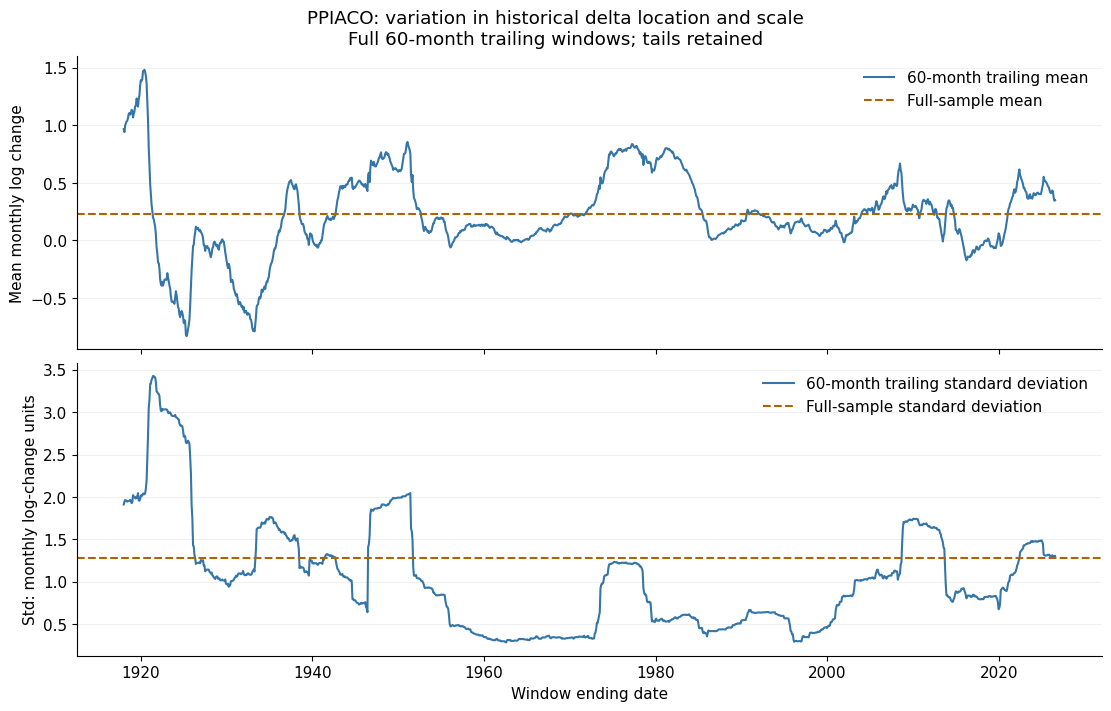

In [10]:
adf_level=adfuller(data.level,regression='ct',autolag='AIC')
adf_delta=adfuller(delta,regression='c',autolag='AIC')
with warnings.catch_warnings(record=True) as captured:
 warnings.simplefilter('always');kpss_delta=kpss(delta,regression='c',nlags='auto')
kpss_warnings=[str(w.message).strip() for w in captured]
tests=pd.DataFrame([
 {'test':'ADF level: constant + trend','statistic':adf_level[0],'p_value':adf_level[1],'lags':adf_level[2],'observations':adf_level[3],'null':'Unit root','reject_at_5pct':adf_level[1]<.05},
 {'test':'ADF delta: constant','statistic':adf_delta[0],'p_value':adf_delta[1],'lags':adf_delta[2],'observations':adf_delta[3],'null':'Unit root','reject_at_5pct':adf_delta[1]<.05},
 {'test':'KPSS delta: constant','statistic':kpss_delta[0],'p_value':kpss_delta[1],'lags':kpss_delta[2],'observations':len(delta),'null':'Level stationarity','reject_at_5pct':kpss_delta[1]<.05}])
table(tests)
for message in kpss_warnings:display(Markdown('**KPSS p-value limitation:** '+message))
zero_change_pct=100*valid.level.eq(valid.previous_level).mean()
level_acf=data.level.autocorr(lag=1);delta_acf=delta.autocorr(lag=1)
calendar_delta=valid.set_index('date').delta_log_pct.reindex(pd.date_range(data.date.min(),data.date.max(),freq='MS'))
rolling_mean=calendar_delta.rolling(60,min_periods=60).mean()
rolling_std=calendar_delta.rolling(60,min_periods=60).std(ddof=1)
volatility_ratio=rolling_std.quantile(.9)/rolling_std.quantile(.1)
mean_span_sigma=(rolling_mean.max()-rolling_mean.min())/sigma
diagnostics={'level_autocorrelation_lag_1':level_acf,'delta_autocorrelation_lag_1':delta_acf,
 'skewness':delta.skew(),'excess_kurtosis':delta.kurt(),'zero_change_pct':zero_change_pct,
 'rolling_std_P90_div_P10':volatility_ratio,'rolling_mean_range_div_full_sample_std':mean_span_sigma,
 'complete_60_month_windows':int(rolling_std.notna().sum())}
table(pd.DataFrame({'diagnostic':diagnostics.keys(),'value':diagnostics.values()}))
fig,(a,b)=plt.subplots(2,1,figsize=(11,7),sharex=True,layout='constrained')
a.plot(rolling_mean.index,rolling_mean,color='#3576A8',label='60-month trailing mean')
a.axhline(mu,color='#AB6400',ls='--',label='Full-sample mean')
a.set_ylabel('Mean monthly log change');a.legend(frameon=False)
b.plot(rolling_std.index,rolling_std,color='#3576A8',label='60-month trailing standard deviation')
b.axhline(sigma,color='#AB6400',ls='--',label='Full-sample standard deviation')
b.set(ylabel='Std: monthly log-change units',xlabel='Window ending date');b.legend(frameon=False)
for ax in (a,b):ax.grid(axis='y',alpha=.18)
fig.suptitle('PPIACO: variation in historical delta location and scale\nFull 60-month trailing windows; tails retained')
plt.show();plt.close(fig)


## 11. Computed audit summary

**Exploratory rubric, not a calibrated model:** fewer than 120 deltas, invalid/zero variance, or simultaneous ADF non-rejection and KPSS rejection gives NOT SUITABLE. Otherwise, KPSS rejection, rolling-standard-deviation P90/P10 > 3, or rolling-mean range > 1 full-sample standard deviation gives REGIME-SENSITIVE. Remaining cases with ADF non-rejection, absolute skewness > 1, excess kurtosis > 3, zero changes > 10%, or absolute lag-1 delta correlation > 0.3 give PASS WITH CAUTION. Only no flags gives PASS.

Rolling thresholds screen for instability; they are not formal break tests. The label describes limitations of one unconditional full-history reference, not the economic interpretability of log growth. A research GOOD label can coexist with a REGIME-SENSITIVE audit verdict.

In [11]:
unsuitable=(len(delta)<120 or not np.isfinite(sigma) or sigma<=0 or (adf_delta[1]>=.05 and kpss_delta[1]<.05))
regime_flags=[]
if kpss_delta[1]<.05:regime_flags.append('KPSS rejects constant-mean stationarity')
if volatility_ratio>3:regime_flags.append(f'rolling volatility P90/P10 = {volatility_ratio:.2f}, above 3')
if mean_span_sigma>1:regime_flags.append(f'rolling mean spans {mean_span_sigma:.2f} full-sample sigma, above 1')
caution_flags=[]
if adf_delta[1]>=.05:caution_flags.append('ADF does not reject a delta unit root')
if abs(delta.skew())>1:caution_flags.append('absolute skewness exceeds 1')
if delta.kurt()>3:caution_flags.append(f'excess kurtosis = {delta.kurt():.2f}, above 3')
if zero_change_pct>10:caution_flags.append(f'zero changes = {zero_change_pct:.2f}%, above 10%')
if abs(delta_acf)>.3:caution_flags.append(f'delta lag-1 correlation = {delta_acf:.3f}, above 0.3 in magnitude')
audit_label='NOT SUITABLE' if unsuitable else 'REGIME-SENSITIVE' if regime_flags else 'PASS WITH CAUTION' if caution_flags else 'PASS'
reasons='Insufficient history, invalid scale, or conflicting stationarity evidence.' if unsuitable else '; '.join(regime_flags+caution_flags) or 'No flags triggered.'
summary=(f'### Audit verdict: {audit_label}\n\n'
 '**Series:** PPIACO - Producer Price Index: All Commodities.  \n'
 '**Recommended transformation:** 100 times one-month log difference.  \n'
 '**Benchmark representation:** Historical Delta Distribution, as a retrospective reference.  \n'
 '**Normalization:** z-score plus empirical percentile.  \n'
 '**Tail treatment:** retain all observations.  \n'
 '**Primary interpretation:** how unusual current monthly PPIACO movement is relative to its own historical monthly movement distribution.\n\n'
 f'**Evidence:** {reasons}.\n\n'
 f'Delta ADF p = {adf_delta[1]:.3g}; KPSS returned p = {kpss_delta[1]:.3g} (see its lookup-table limitation). '
 'Unit-root/mean-stationarity tests do not establish stable volatility. Full-history rarity remains sensitive to the period and regime.\n\n'
 f'Latest snapshot ({latest.date:%Y-%m-%d}): log change {latest.delta_log_pct:.4f}, z {latest.z_delta:.3f}, '
 f'empirical percentile {latest.percentile_rank:.2f}, state **{latest.delta_state}**. Direction is relative to mean change.\n\n'
 'Extreme PPIACO does not automatically establish inflation, a supply shock, or stagflation. '
 'Later cross-checks should include PPIFID, CPI, Core CPI, PCE inflation, Industrial Production, Manufacturing Production, '
 'Capacity Utilization, user-provided commodity/oil/energy information, and external supporting evidence. '
 'No event causes are assigned here.')
display(Markdown(summary))


### Audit verdict: REGIME-SENSITIVE

**Series:** PPIACO - Producer Price Index: All Commodities.  
**Recommended transformation:** 100 times one-month log difference.  
**Benchmark representation:** Historical Delta Distribution, as a retrospective reference.  
**Normalization:** z-score plus empirical percentile.  
**Tail treatment:** retain all observations.  
**Primary interpretation:** how unusual current monthly PPIACO movement is relative to its own historical monthly movement distribution.

**Evidence:** rolling volatility P90/P10 = 5.53, above 3; rolling mean spans 1.81 full-sample sigma, above 1; excess kurtosis = 12.33, above 3; zero changes = 16.29%, above 10%; delta lag-1 correlation = 0.487, above 0.3 in magnitude.

Delta ADF p = 9.78e-17; KPSS returned p = 0.1 (see its lookup-table limitation). Unit-root/mean-stationarity tests do not establish stable volatility. Full-history rarity remains sensitive to the period and regime.

Latest snapshot (2026-08-01): log change 0.9586, z 0.568, empirical percentile 82.61, state **NORMAL POSITIVE**. Direction is relative to mean change.

Extreme PPIACO does not automatically establish inflation, a supply shock, or stagflation. Later cross-checks should include PPIFID, CPI, Core CPI, PCE inflation, Industrial Production, Manufacturing Production, Capacity Utilization, user-provided commodity/oil/energy information, and external supporting evidence. No event causes are assigned here.

In [12]:
assert all(digest(ROOT/path)==h for path,h in source_hashes.items())
assert len(valid)==len(raw)-1 and len(data)==len(raw)
assert valid[['delta_log_pct','z_delta','percentile_rank','delta_state']].notna().all().all()
print('Verified: cleaned CSVs and analysis.ipynb unchanged; all valid changes and tails retained.')
print('Python',platform.python_version(),'pandas',pd.__version__,'NumPy',np.__version__,
 'SciPy',scipy.__version__,'statsmodels',statsmodels.__version__,'matplotlib',matplotlib.__version__)
table(pd.DataFrame([{'source_file':str(p.relative_to(ROOT)),'sha256':source_hashes[str(p.relative_to(ROOT))]} for p in [SOURCE,REFERENCE]]))


Verified: cleaned CSVs and analysis.ipynb unchanged; all valid changes and tails retained.
Python 3.14.2 pandas 3.0.2 NumPy 2.4.4 SciPy 1.17.1 statsmodels 0.14.6 matplotlib 3.10.8


source_file,sha256
data\cleaned\PPIACO.csv,773abac12899c316cb334d286bfefbf2247ebea5b95caa28d271ea58855bcbdc
notebook\deltaAnalysis\analysis.ipynb,8692512bbe246ff6fb29b64c6c4011999b9ff4f10173531f1d2a6c84f4dfdf87
